In [1]:
import os
import numpy as np
import tensorflow as tf
import cv2 as cv
from tqdm import tqdm
import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16, preprocess_input
import tensorflow.keras.layers as tfl
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
def loadData(dir_path):
    X = []
    y = []
    labels = dict()
    i = 0
    for path in tqdm(sorted(os.listdir(dir_path))): #traverse through directories under Train/Val/Test
        if not path.startswith('.'):
            labels[i] = path
            for file in os.listdir(dir_path+'\\'+path):
                if not file.startswith('.'):
                    img = cv.imread(dir_path+'\\'+path+'\\'+file)
                    X.append(img)
                    y.append(i)
            i=i+1
    X = np.array(X,dtype='object')
    y = np.array(y)
    print(f'{len(X)} images loaded from {dir_path} directory.')
    return X,y,labels


In [3]:
X_train, y_train, labels = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TRAIN')
X_val, y_val, _ = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\VAL')
X_test, y_test, _ = loadData(r'C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TEST')
IMG_SIZE = (64,64)

100%|██████████| 2/2 [00:00<00:00, 17.09it/s]


559 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TRAIN directory.


100%|██████████| 2/2 [00:00<00:00, 162.76it/s]


64 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\VAL directory.


100%|██████████| 2/2 [00:00<00:00, 136.77it/s]

65 images loaded from C:\Users\sriha\OneDrive\Desktop\Projects\PD_Project\TEST directory.


In [4]:
def preprocess_imgs(set, img_size):
    set_new = []
    for img in set:
        img = cv.resize(img, dsize=img_size, interpolation=cv.INTER_CUBIC)
        set_new.append(preprocess_input(img))
    return np.array(set_new)

In [5]:
X_train_fin = preprocess_imgs(set=X_train,img_size=IMG_SIZE)
X_val_fin = preprocess_imgs(set=X_val,img_size=IMG_SIZE)
X_test_fin = preprocess_imgs(set=X_test,img_size=IMG_SIZE)

In [6]:
model = tf.keras.Sequential([
        tfl.ZeroPadding2D(padding=(3,3), input_shape=(64,64,3)),
        tfl.Conv2D(filters = 32, strides = 1, kernel_size=(7,7)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.Conv2D(filters = 64, strides = 1, kernel_size=(5,5)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.Conv2D(filters = 64, strides = 1, kernel_size=(3,3)),
        tfl.BatchNormalization(axis=-1),
        tfl.ReLU(),
        tfl.MaxPool2D(),
        tfl.Flatten(),
        tfl.Dense(units = 1, activation = 'sigmoid')
    ])

In [7]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics='accuracy')
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 zero_padding2d (ZeroPadding  (None, 70, 70, 3)        0         
 2D)                                                             
                                                                 
 conv2d (Conv2D)             (None, 64, 64, 32)        4736      
                                                                 
 batch_normalization (BatchN  (None, 64, 64, 32)       128       
 ormalization)                                                   
                                                                 
 re_lu (ReLU)                (None, 64, 64, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 60, 60, 64)        51264     
                                                                 
 batch_normalization_1 (Batc  (None, 60, 60, 64)       2

                                                                 
 conv2d_2 (Conv2D)           (None, 58, 58, 64)        36928     
                                                                 
 batch_normalization_2 (Batc  (None, 58, 58, 64)       256       
 hNormalization)                                                 
                                                                 
 re_lu_2 (ReLU)              (None, 58, 58, 64)        0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 29, 29, 64)       0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 53824)             0         
                                                                 
 dense (Dense)               (None, 1)                 53825     
                                                                 
Total para

In [8]:
def plot_roc_curve(true_y, y_prob):

    fpr, tpr, thresholds = metrics.roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

In [9]:
model.fit(X_train_fin,y_train,epochs=15,batch_size=32)

Epoch 1/15
18/18 [==============================] - 7s 321ms/step - loss: 1.4000 - accuracy: 0.7513
Epoch 2/15
18/18 [==============================] - 6s 308ms/step - loss: 0.2714 - accuracy: 0.9231
Epoch 3/15
18/18 [==============================] - 5s 297ms/step - loss: 0.2283 - accuracy: 0.9267
Epoch 4/15
18/18 [==============================] - 5s 299ms/step - loss: 0.3613 - accuracy: 0.8891
Epoch 5/15
18/18 [==============================] - 5s 293ms/step - loss: 0.2883 - accuracy: 0.9392
Epoch 6/15
18/18 [==============================] - 5s 302ms/step - loss: 0.2001 - accuracy: 0.9481
Epoch 7/15
18/18 [==============================] - 5s 301ms/step - loss: 0.1538 - accuracy: 0.9481
Epoch 8/15
18/18 [==============================] - 5s 300ms/step - loss: 0.1621 - accuracy: 0.9410
Epoch 9/15
18/18 [==============================] - 5s 302ms/step - loss: 0.0838 - accuracy: 0.9767
Epoch 10/15
18/18 [==============================] - 6s 305ms/step - loss: 0.0831 - accuracy: 0.9642

In [10]:
model.evaluate(X_val_fin,y_val)

2/2 [==============================] - 0s 77ms/step - loss: 0.1253 - accuracy: 0.9688


[0.12526579201221466, 0.96875]

In [11]:
model.evaluate(X_test_fin,y_test)

3/3 [==============================] - 0s 42ms/step - loss: 0.0280 - accuracy: 1.0000


[0.028045915067195892, 1.0]

In [12]:
yhat_val = model.predict(X_val_fin)
yhat_val_fin = [1 if x>=0.5 else 0 for x in yhat_val]
yhat_test = model.predict(X_test_fin)
yhat_test_fin = [1 if x>=0.5 else 0 for x in yhat_test]


3/3 [==============================] - 0s 41ms/step


F1 measure: 0.9761904761904763
ROC AUC: 0.9767441860465116


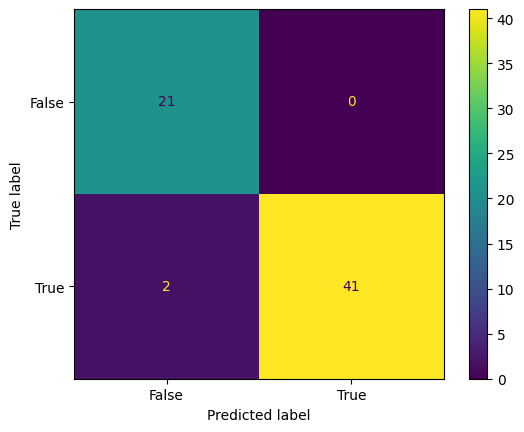

In [13]:
confusion_matrix_val = metrics.confusion_matrix(y_val,yhat_val_fin)
cmv = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_val, display_labels = [False, True])
# plot_roc_curve(y_val,yhat_val_fin)
print(f'F1 measure: {metrics.f1_score(y_val,yhat_val_fin)}\nROC AUC: {metrics.roc_auc_score(y_val,yhat_val_fin)}')
cmv.plot()
plt.show()

F1 measure: 1.0
ROC AUC: 1.0


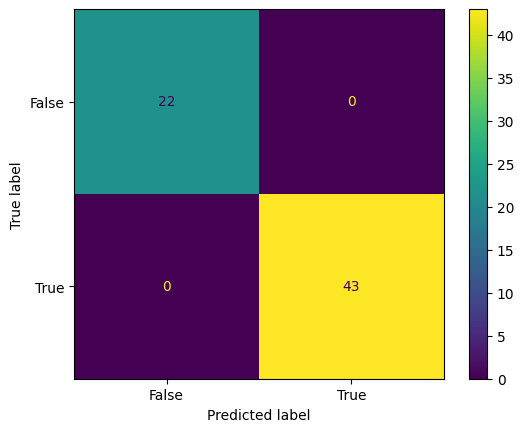

In [14]:
confusion_matrix_test = metrics.confusion_matrix(y_test,yhat_test_fin)
cmt = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix_test, display_labels = [False, True])
# plot_roc_curve(y_test,yhat_test_fin)
print(f'F1 measure: {metrics.f1_score(y_test,yhat_test_fin)}\nROC AUC: {metrics.roc_auc_score(y_test,yhat_test_fin)}')
cmt.plot()
plt.show()